# Group the Actinobacteria genomes by order

How common are the genes of the two arabinose pathways in each Actinobacteria order? For every large order, this
notebook computes the fraction of genomes with a passing HMM hit for each gene, and shows it as a heatmap next to
an order-level tree. *Streptomyces* and the other Streptomycetaceae get their own rows, using the larger
Streptomycetae genome set.

- **vnz/Ara pathway:** lacI-AraR, AraB, AraA, AraD
- **SCO pathway:** SCO2401, SCO2402, SCO2403, SCO2407, SCO2439, SCO2440

## Steps

1. **Setup**: file locations and the genes of the two pathways.
2. **Load taxonomy**: the NCBI class, order, family and genus of every genome.
3. **Match genome names**: find the name each genome has in the HMM results.
4. **Select large orders**: keep the orders with enough genomes for a fraction.
5. **Load passing HMM hits**: the best hit per genome and gene that passed the threshold.
6. **Add taxonomy to the hits**: give every passing hit its order.
7. **Count per order**: number of genomes with a passing hit, per order and gene.
8. **Streptomycetaceae genomes**: collect the *Streptomyces* and other Streptomycetaceae genomes from both genome sets.
9. **Streptomycetaceae counts**: count them and put them in place of the Kitasatosporales row.
10. **Order tree**: reduce the whole-genome tree to one tip per order.
11. **Heatmap**: fractions per order and gene, drawn next to the tree.

## Step 1: Setup

Loads the libraries and defines where the files are and which genes belong to each pathway.

**Input:** none

**Output:**
- `PATHWAYS`: the genes of the vnz/Ara pathway and of the SCO pathway
- `gene_columns`: all 10 genes, in the column order of the heatmap

**How:** the gene order is taken from `PATHWAYS`, vnz/Ara genes first and then the SCO genes, so the two pathways
sit side by side in the heatmap.

In [1]:
# Step 1: Setup
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from Bio import Phylo
from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap

PROJECT_DIR = Path("/vol/local/calarass/Projects/ara_comp_genomics")
TAXONOMY_DIR = PROJECT_DIR / "taxonomy_heatmap" / "results" / "taxonomy"
PATH_TO_HMM_DIR = PROJECT_DIR / "hmm_search" / "results"
GENOMES_DIR = Path("/vol/local/calarass/Projects/lipid_genomics/actinos/genomes")

PATHWAYS = {
    "vnz/Ara": ["lacI-AraR", "AraB", "AraA", "AraD"],
    "SCO": ["SCO2401", "SCO2402", "SCO2403", "SCO2407", "SCO2439", "SCO2440"],
}
GENE_TO_PATHWAY = {gene: pathway for pathway, genes in PATHWAYS.items() for gene in genes}
# heatmap columns: vnz/Ara genes first, then the SCO genes
gene_columns = [gene for genes in PATHWAYS.values() for gene in genes]

for pathway, genes in PATHWAYS.items():
    print(f"{pathway}: {', '.join(genes)}")

vnz/Ara: lacI-AraR, AraB, AraA, AraD
SCO: SCO2401, SCO2402, SCO2403, SCO2407, SCO2439, SCO2440


## Step 2: Load taxonomy

Reads the NCBI taxonomy of every Actinobacteria genome.

**Input:**
- `taxonomy_orders.tsv`: one row per genome with its taxonomy (from `01_get_taxonomy.py`)
- `order_counts.tsv`: the number of genomes per order (from `01_get_taxonomy.py`)

**Output:**
- `taxonomy`: one row per genome, with its assembly, taxid, class, order, family and genus
- `order_counts`: one row per order, with its class and number of genomes

**How:** `01_get_taxonomy.py` looked up the taxid of each genome at NCBI; both files are read as they are.

In [2]:
# Step 2: Load taxonomy
taxonomy = pd.read_csv(TAXONOMY_DIR / "taxonomy_orders.tsv", sep="\t")
order_counts = pd.read_csv(TAXONOMY_DIR / "order_counts.tsv", sep="\t")

print(f"{len(taxonomy)} genomes in {len(order_counts)} orders")
display(taxonomy.head())
order_counts

253 genomes in 32 orders


,genome,assembly,taxid,class,order,family,genus
0,Acidimicrobium_ferrooxidans_DSM_10331,GCF_000023265.1,525909,Acidimicrobiia,Acidimicrobiales,Acidimicrobiaceae,Acidimicrobium
1,Acidipropionibacterium_acidipropionici_ATCC_4875,GCF_000310065.1,1171373,Actinomycetes,Propionibacteriales,Propionibacteriaceae,Acidipropionibacterium
2,Acidothermaceae_bacterium_B102,GCA_033097465.1,3061014,Actinomycetes,Acidothermales,Acidothermaceae,NaN
3,Acidothermus_cellulolyticus_11B_ATCC_43068,GCF_000015025.1,351607,Actinomycetes,Acidothermales,Acidothermaceae,Acidothermus
4,Actinacidiphila_bryophytorum_DS3,GCF_024927965.1,1436133,Actinomycetes,Kitasatosporales,Streptomycetaceae,Actinacidiphila


,class,order,genomes
0,Acidimicrobiia,Acidimicrobiales,6
1,Actinomycetes,Micrococcales,93
2,Actinomycetes,Mycobacteriales,22
3,Actinomycetes,Propionibacteriales,19
4,Actinomycetes,Pseudonocardiales,15
5,Actinomycetes,Actinomycetales,14
6,Actinomycetes,Micromonosporales,11
7,Actinomycetes,Streptosporangiales,9
8,Actinomycetes,Kitasatosporales,8
9,Actinomycetes,Bifidobacteriales,4


## Step 3: Match genome names

Finds, for every genome, the name it has in the HMM results.

**Input:**
- `taxonomy`: the genomes and their taxonomy (step 2)
- the GenBank file (`.gbff`) in each genome folder of `lipid_genomics/actinos/genomes/`

**Output:**
- `taxonomy.hmm_name` (new column): the genome name as used in the `.faa` files and the HMM hits

**How:** the taxonomy table uses the genome folder names, but the `.faa` files, and so the HMM hits, are named
after the organism in each genome's GenBank file, e.g. `Acidothermus_cellulolyticus_11B_ATCC_43068` vs
`Acidothermus_cellulolyticus_11B`; only 75 of the 253 names are identical. The organism name is read from the
`ORGANISM` line of the `.gbff` (joining the line it continues on when the name is long), spaces become `_` and the
square brackets NCBI puts around doubtful genera are removed, as in the file names (e.g. `[Actinomadura]_parvosata`).
A genome without a `.gbff` has no `.faa` file, so it was not searched with the HMMs and gets no name.

In [3]:
# Step 3: Match genome names
def organism_name(genome_dir):
    """Organism name of a genome folder as used for its .faa/.tblout file, or None."""
    gbff = next(genome_dir.glob("ncbi_dataset/data/*/genomic.gbff"), None)
    if gbff is None:
        return None
    with open(gbff) as fh:
        for line in fh:
            if line.startswith("  ORGANISM"):
                parts = [line[12:].strip()]
                # long names wrap onto the next line; the lineage lines that
                # follow contain ';'
                for line in fh:
                    if ";" in line or not line.startswith(" " * 12):
                        break
                    parts.append(line.strip())
                name = " ".join(parts).replace(" ", "_")
                return name.replace("[", "").replace("]", "")
    return None


taxonomy["hmm_name"] = [organism_name(GENOMES_DIR / genome) for genome in taxonomy.genome]

# genomes without a .gbff have no .faa, so they were not searched with the HMMs
matched = taxonomy.hmm_name.notna()
print(f"{matched.sum()} of {len(taxonomy)} genomes have a .faa name")
print("no .faa name:")
print(taxonomy.loc[~matched, ["genome", "order"]].to_string(index=False))
taxonomy[["genome", "hmm_name", "order"]]

252 of 253 genomes have a .faa name
no .faa name:
                   genome         order
Allobranchiibius_GilTou73 Micrococcales


,genome,hmm_name,order
0,Acidimicrobium_ferrooxidans_DSM_10331,Acidimicrobium_ferrooxidans_DSM_10331,Acidimicrobiales
1,Acidipropionibacterium_acidipropionici_ATCC_4875,Acidipropionibacterium_acidipropionici_ATCC_4875,Propionibacteriales
2,Acidothermaceae_bacterium_B102,Acidothermaceae_bacterium_B102,Acidothermales
3,Acidothermus_cellulolyticus_11B_ATCC_43068,Acidothermus_cellulolyticus_11B,Acidothermales
4,Actinacidiphila_bryophytorum_DS3,Actinacidiphila_bryophytorum,Kitasatosporales
...,...,...,...
248,Winkia_neuii_UMB0125,Winkia_neuii,Actinomycetales
249,Xiamenia_xianingshaonis_zg-886,Xiamenia_xianingshaonis,Eggerthellales
250,Xylanimonas_cellulosilytica_DSM_15894,Xylanimonas_cellulosilytica_DSM_15894,Micrococcales
251,Yimella_cx-51,Yimella_sp._cx-51,Micrococcales


## Step 4: Select large orders

Keeps the orders with enough genomes for a meaningful fraction.

**Input:**
- `order_counts`: the number of genomes per order (step 2)
- `taxonomy`: the genomes, their order and HMM name (step 3)

**Output:**
- `large_orders`: the orders shown in the heatmap
- `searched`: the genomes of those orders that were searched with the HMMs

**How:** an order is kept if it has at least 9 genomes; Kitasatosporales, the order of *Streptomyces*, is always
kept as the reference order of the study. `searched` is every genome of these orders with an HMM name, with or
without a passing hit: its number per order is the denominator of the fractions.

In [4]:
# Step 4: Select large orders
MIN_GENOMES = 9
ALWAYS_KEEP = ["Kitasatosporales"]  # Streptomyces and relatives: the reference order of the study

large_orders = order_counts[(order_counts.genomes >= MIN_GENOMES) | order_counts.order.isin(ALWAYS_KEEP)]

# genomes searched with the HMMs (the ones with a .faa name) in the large orders: the n_genomes of each
# order, including the genomes without any passing hit
# eg Allobranchiibius_GilTou73 is listed in the COG table, but its genome was never downloaded or saved
tbl_searched_largeOrders = taxonomy[taxonomy.hmm_name.notna() & taxonomy.order.isin(large_orders.order)]

print(f"{len(large_orders)} orders with >= {MIN_GENOMES} genomes (+ {', '.join(ALWAYS_KEEP)}): "
      f"{large_orders.genomes.sum()} of {order_counts.genomes.sum()} genomes, {len(tbl_searched_largeOrders)} searched with the HMMs")
large_orders.assign(searched=large_orders.order.map(tbl_searched_largeOrders.groupby("order").size()))

10 orders with >= 9 genomes (+ Kitasatosporales): 210 of 253 genomes, 209 searched with the HMMs


,class,order,genomes,searched
1,Actinomycetes,Micrococcales,93,92
2,Actinomycetes,Mycobacteriales,22,22
3,Actinomycetes,Propionibacteriales,19,19
4,Actinomycetes,Pseudonocardiales,15,15
5,Actinomycetes,Actinomycetales,14,14
6,Actinomycetes,Micromonosporales,11,11
7,Actinomycetes,Streptosporangiales,9,9
8,Actinomycetes,Kitasatosporales,8,8
23,Coriobacteriia,Eggerthellales,10,10
24,Coriobacteriia,Coriobacteriales,9,9


## Step 5: Load passing HMM hits

Reads the HMM hits that count as "gene present".

**Input:**
- `actino_top_hits_passed.tsv`: HMM hits in the Actinobacteria genomes that passed the threshold (from
  `07_selection_criteria.ipynb`)

**Output:**
- `actino_passes`: one row per genome and gene with a passing hit

**How:** the file is already filtered in `07_selection_criteria.ipynb`: per genome and HMM model only the
best-scoring protein is kept, and only if its bitscore reaches the threshold of that model. Nothing is filtered
here.

In [5]:
# Step 5: Load passing HMM hits
actino_passes = pd.read_csv(PATH_TO_HMM_DIR / "actino_top_hits_passed.tsv", sep="\t")


print(f"{len(actino_passes)} passing best hits from {actino_passes.tblout.nunique()} genomes")
actino_passes.query_gene.value_counts()

347 passing best hits from 125 genomes


query_gene
AraD         113
AraA         101
AraB          70
lacI-AraR     17
SCO2403       11
SCO2440       11
SCO2402        9
SCO2401        8
SCO2439        5
SCO2407        2
Name: count, dtype: int64

## Step 6: Add taxonomy to the hits

Gives every passing hit the order of its genome.

**Input:**
- `actino_passes`: the passing hits (step 5)
- `tbl_searchedHMM_bigOrders`: the genomes of the large orders, with their taxonomy (step 4)

**Output:**
- `actino_hmm_taxonomy`: the passing hits of the genomes in the large orders, with class, order, family and genus

**How:** the hits and the genomes are joined on the genome name: the `tblout` column of the hits (the `.faa` file
name) against `hmm_name`. Only hits whose genome is in a large order are kept. The check above the join lists hits
whose genome is missing from the taxonomy table; it should be empty.

In [6]:
# Step 6: Add taxonomy to the hits
print("hits without taxonomy:", sorted(set(actino_passes.tblout) - set(taxonomy.hmm_name)))

# tblout = .faa/.tblout name = taxonomy.hmm_name; the inner merge keeps only the genomes in the large orders
actino_hmm_taxonomy = actino_passes.merge(
    tbl_searched_largeOrders[["genome", "hmm_name", "assembly", "class", "order", "family", "genus"]]
        .rename(columns={"genome": "taxonomy_genome"}),
    left_on="tblout", right_on="hmm_name", how="inner",
)

print(f"{len(actino_hmm_taxonomy)} passing hits from {actino_hmm_taxonomy.tblout.nunique()} of "
      f"{len(tbl_searched_largeOrders)} genomes in {tbl_searched_largeOrders.order.nunique()} orders")
actino_hmm_taxonomy[["tblout", "order", "query_gene", "bitscore", "threshold"]]

hits without taxonomy: []
294 passing hits from 106 of 209 genomes in 10 orders


,tblout,order,query_gene,bitscore,threshold
0,Actinokineospora_sp._UTMC_2448,Pseudonocardiales,AraB,1033.8,550.65
1,Crossiella_sp._CA-258035,Pseudonocardiales,AraB,1025.2,550.65
2,Lentzea_guizhouensis,Pseudonocardiales,AraB,1025.0,550.65
3,Actinosynnema_mirum_DSM_43827,Pseudonocardiales,AraB,1017.4,550.65
4,Paenarthrobacter_aurescens_TC1,Micrococcales,AraB,1014.8,550.65
...,...,...,...,...,...
289,Natronosporangium_hydrolyticum,Micromonosporales,SCO2403,353.3,349.00
290,Lysinibacter_sp._HNR,Micrococcales,AraD,350.5,291.00
291,Propionibacterium_freudenreichii_subsp._freude...,Propionibacteriales,AraD,332.7,291.00
292,Subtercola_endophyticus,Micrococcales,AraD,301.7,291.00


## Step 7: Count per order

Counts, per order and gene, how many genomes have a passing hit.

**Input:**
- `actino_hmm_taxonomy`: the passing hits with their order (step 6)
- `tbl_searched_largeOrders`: the genomes of the large orders (step 4)

**Output:**
- `contingency`: one row per order, one column per gene with the number of genomes with a passing hit, plus
  `n_genomes`, the number of genomes searched in that order

**How:** `crosstab` counts the hits for each combination of order and gene; a genome has at most one best hit per
gene, so this is the number of genomes. `reindex` then puts in all large orders and all genes, in the heatmap order,
and fills the combinations without any hit with 0.

In [7]:
# Step 7: Count per order
# a genome with several passing copies of a gene is counted once
genome_gene = actino_hmm_taxonomy.drop_duplicates(["tblout", "query_gene"])
contingency = (
    pd.crosstab(genome_gene.order, genome_gene.query_gene)
    .reindex(index=large_orders.order, columns=gene_columns, fill_value=0)
)
# genomes searched per order (with or without passing hits), for the fractions in step 11
contingency.insert(0, "n_genomes", tbl_searched_largeOrders.groupby("order").size())
contingency

query_gene,n_genomes,lacI-AraR,AraB,AraA,AraD,SCO2401,SCO2402,SCO2403,SCO2407,SCO2439,SCO2440
order,,,,,,,,,,,
Micrococcales,92,1,21,45,46,0,0,0,0,0,0
Mycobacteriales,22,0,2,2,2,0,0,0,0,0,0
Propionibacteriales,19,0,7,10,11,0,1,0,0,0,1
Pseudonocardiales,15,1,5,5,5,2,3,2,0,3,2
Actinomycetales,14,0,5,5,8,0,0,0,0,0,0
Micromonosporales,11,0,6,8,8,2,1,2,1,0,4
Streptosporangiales,9,3,4,2,4,0,0,2,0,0,1
Kitasatosporales,8,5,4,4,4,2,2,2,1,2,2
Eggerthellales,10,0,0,0,0,0,0,0,0,0,0


In [8]:
## Double check using the contingency table imported from script 
# Projects/ara_comp_genomics/hmm_search/results/correlation_matrix_actinos.csv
contigency_from_script = pd.read_csv(PROJECT_DIR / "hmm_search" / "results" / "correlation_matrix_actinos.csv", index_col=0).rename_axis("genome_name").reset_index()
contigency_from_script

# merge with the tbl_searched_largeOrders to get the n_genomes column

tbl = tbl_searched_largeOrders.assign(tree_name=tbl_searched_largeOrders.hmm_name.str.replace(r"[=()]", "_", regex=True))
contingency_from_script = contigency_from_script.merge(tbl[["tree_name", "order"]], left_on="genome_name", right_on="tree_name", how="inner")
contingency_from_script.groupby("order").sum()


#contingency_from_script = contigency_from_script.merge(tbl_searched_largeOrders[["hmm_name", "order"]], left_on="genome_name", right_on="hmm_name", how="left")
#contingency_from_script


,genome_name,AraA,AraB,AraD,SCO2401,SCO2402,SCO2403,SCO2407,SCO2439,SCO2440,lacI-AraR,tree_name
order,,,,,,,,,,,,
Actinomycetales,Actinobaculum_sp._313Actinomyces_naeslundiiAct...,5,5,8,0,0,0,0,0,0,0,Actinobaculum_sp._313Actinomyces_naeslundiiAct...
Coriobacteriales,Atopobium_sp._oral_taxon_416Collinsella_aerofa...,2,0,0,0,0,0,0,0,0,0,Atopobium_sp._oral_taxon_416Collinsella_aerofa...
Eggerthellales,Adlercreutzia_equolifaciens_DSM_19450Berryella...,0,0,0,0,0,0,0,0,0,0,Adlercreutzia_equolifaciens_DSM_19450Berryella...
Kitasatosporales,Actinacidiphila_bryophytorumKitasatospora_seta...,4,4,4,2,2,2,1,2,2,5,Actinacidiphila_bryophytorumKitasatospora_seta...
Micrococcales,Actinotalea_sp._JY-7876Agreia_sp._COWGAgrococc...,45,21,46,0,0,0,0,0,0,1,Actinotalea_sp._JY-7876Agreia_sp._COWGAgrococc...
Micromonosporales,Actinocatenispora_seraActinoplanes_friuliensis...,8,6,8,2,1,2,1,0,4,0,Actinocatenispora_seraActinoplanes_friuliensis...
Mycobacteriales,Corynebacterium_diphtheriaeCorynebacterium_glu...,2,2,2,0,0,0,0,0,0,0,Corynebacterium_diphtheriaeCorynebacterium_glu...
Propionibacteriales,Acidipropionibacterium_acidipropionici_ATCC_48...,10,7,11,0,1,0,0,0,1,0,Acidipropionibacterium_acidipropionici_ATCC_48...
Pseudonocardiales,Actinoalloteichus_hoggarensisActinokineospora_...,5,5,5,2,3,2,0,3,2,1,Actinoalloteichus_hoggarensisActinokineospora_...


## Step 8: Streptomycetaceae genomes

Collects the *Streptomyces* and other Streptomycetaceae genomes of both genome sets.

**Input:**
- `strep_top_hits.tsv`: the best hits in the Streptomycetae genome set, with pass/fail (from
  `07_selection_criteria.ipynb`)
- `searched`: the Kitasatosporales genomes of the Actinobacteria set (step 4)
- `actino_hmm_taxonomy`: their passing hits (step 6)

**Output:**
- `strep_genomes`: every Streptomycetaceae genome of the two sets, each once
- `strep_present`: their passing hits, each labelled *Streptomyces* or other Streptomycetaceae

**How:** the Actinobacteria set has only 8 Kitasatosporales genomes (2 *Streptomyces*); the Streptomycetae set
(207 genomes) was searched with the same HMMs and called against the same thresholds. A genome in both sets is
counted once, from the Streptomycetae set; names are compared on their letters and digits only, since the two sets
write punctuation differently. The genus at the start of the name decides the row; *[Kitasatospora] papulosa* counts
as *Streptomyces* because it sits inside *Streptomyces* in the Streptomycetae tree.

In [9]:
# Step 8: Streptomycetaceae genomes
STREP_ROWS = ["Streptomyces", "other Streptomycetaceae"]
STREP_ROWS = ["Streptomyces", "other Kitasatosporales"]
COUNT_AS_STREPTOMYCES = {"Kitasatospora_papulosa"}


def name_key(name):
    """Compare genome names of the two sets on letters and digits only.

    e.g. 'Streptantibioticus_cattleyicolor_NRRL_8057_=_DSM_46488' and
         'Streptantibioticus_cattleyicolor_NRRL_8057_DSM_46488'
         both -> 'streptantibioticuscattleyicolornrrl8057dsm46488'
    """
    return re.sub(r"[^a-z0-9]", "", name.lower())


def strep_row(names):
    """Streptomyces or other Streptomycetaceae, from the genus in the genome name.
    Args: names (pd.Series): genome names
    Returns: pd.Series 
    """
    is_streptomyces = (names.str.split("_").str[0] == "Streptomyces") | names.isin(COUNT_AS_STREPTOMYCES)
    return is_streptomyces.map({True: STREP_ROWS[0], False: STREP_ROWS[1]})


strep_hmm_results = pd.read_csv(PATH_TO_HMM_DIR / "strep_top_hits.tsv", sep="\t")
strep_hmm_results["name"] = strep_hmm_results.tblout.str.replace(r"_protein$", "", regex=True)

# Kitasatosporales genomes of the Actinobacteria set that are not in the Streptomycetae set
kitasato = tbl_searched_largeOrders.loc[tbl_searched_largeOrders.order == "Kitasatosporales", "hmm_name"]
in_strep_set = kitasato.map(name_key).isin(set(strep_hmm_results.name.map(name_key)))
added = kitasato[~in_strep_set]

# all genomes of the two rows (for n_genomes) and their passing hits
strep_genomes = pd.Series(sorted(set(strep_hmm_results.name) | set(added)))
strep_present = pd.concat([
    strep_hmm_results.loc[strep_hmm_results.status == "pass", ["name", "query_gene"]],
    actino_hmm_taxonomy.loc[actino_hmm_taxonomy.tblout.isin(added), ["tblout", "query_gene"]]
        .rename(columns={"tblout": "name"}),
], ignore_index=True)
strep_present["row"] = strep_row(strep_present.name)

print("Kitasatosporales genomes in both sets (counted once):", sorted(kitasato[in_strep_set]))
print("added from the Actinobacteria set:", sorted(added))
print(f"{len(strep_present)} passing hits from {strep_present.name.nunique()} of {len(strep_genomes)} genomes")
strep_row(strep_genomes).value_counts().rename("genomes")

Kitasatosporales genomes in both sets (counted once): ['Kitasatospora_setae_KM-6054', 'Peterkaempfera_bronchialis', 'Streptantibioticus_cattleyicolor_NRRL_8057_=_DSM_46488', 'Streptomyces_coelicolor_A3(2)']
added from the Actinobacteria set: ['Actinacidiphila_bryophytorum', 'Streptacidiphilus_sp._P02-A3a', 'Streptomyces_griseus_subsp._griseus_NBRC_13350', 'Yinghuangia_sp._ASG_101']
921 passing hits from 160 of 211 genomes


Streptomyces              194
other Kitasatosporales     17
Name: genomes, dtype: int64

## Step 9: Streptomycetaceae counts

Counts the Streptomycetaceae genomes per gene and puts them in the order table.

**Input:**
- `strep_genomes`, `strep_present`: the Streptomycetaceae genomes and their passing hits (step 8)
- `contingency`: the counts per order (step 7)

**Output:**
- `strep_counts`: the counts for the two rows *Streptomyces* and other Streptomycetaceae
- `contingency` (updated): the Kitasatosporales row replaced by these two rows

**How:** the same counting as in step 7 (`crosstab` + `reindex`), with the number of genomes per row taken from
`strep_genomes`.

In [10]:
# Step 9: Streptomycetaceae counts
# a genome with several passing copies of a gene is counted once
strep_genome_gene = strep_present.drop_duplicates(["name", "query_gene"])
strep_counts = (
    pd.crosstab(strep_genome_gene.row, strep_genome_gene.query_gene)
    .reindex(index=STREP_ROWS, columns=gene_columns, fill_value=0)
)
strep_counts.insert(0, "n_genomes", strep_row(strep_genomes).value_counts())

contingency = pd.concat([contingency.drop(index="Kitasatosporales"), strep_counts])
contingency

query_gene,n_genomes,lacI-AraR,AraB,AraA,AraD,SCO2401,SCO2402,SCO2403,SCO2407,SCO2439,SCO2440
Micrococcales,92,1,21,45,46,0,0,0,0,0,0
Mycobacteriales,22,0,2,2,2,0,0,0,0,0,0
Propionibacteriales,19,0,7,10,11,0,1,0,0,0,1
Pseudonocardiales,15,1,5,5,5,2,3,2,0,3,2
Actinomycetales,14,0,5,5,8,0,0,0,0,0,0
Micromonosporales,11,0,6,8,8,2,1,2,1,0,4
Streptosporangiales,9,3,4,2,4,0,0,2,0,0,1
Eggerthellales,10,0,0,0,0,0,0,0,0,0,0
Coriobacteriales,9,0,0,2,0,0,0,0,0,0,0
Streptomyces,194,39,25,24,26,129,128,127,98,124,130


## Step 10: Order tree

Reduces the whole-genome tree to one tip per order, to set the row order of the heatmap.

**Input:**
- the Actinobacteria whole-genome tree with three outgroups (*Bacillus subtilis*, *Chloroflexus aurantiacus*,
  *Deinococcus radiodurans*; `lipid_genomics/actinos/output_WGS_tree_actinos_with_outgroup/faa.tre.treefile`,
  PhyloPhlAn + IQ-TREE)
- `taxonomy`: the order of every genome (step 3)

Step 10a reads and roots the tree and gives every tip its order; step 10b reduces it to one tip per order.

**Output:**
- `tree`: the tree with one tip per order, and *Streptomyces* / other Streptomycetaceae as two tips
- `order_rows`: the orders from top to bottom, as the heatmap rows
- `not_monophyletic`: the orders that do not form one clade, and what sits inside them

**How:** tree tips are matched to their order on letters and digits only (IQ-TREE replaces `(`, `)`, `=` and
brackets by `_`). The tree is rooted on *Deinococcus*, the outgroup that branches off first, and the three outgroups are
then removed. *Bacillus* does not sit outside the Actinobacteria but next to the Coriobacteriia (likely an artefact
of their long branch), so it is not used as root; after removing the outgroups the root separates Coriobacteriia
from all other Actinobacteria, as the midpoint root did. Genomes outside the
large orders are removed, each order is checked for being one clade, and then only one tip per order is kept and
named after the order. The Kitasatosporales tip is split into the two Streptomycetaceae rows, and the branches are
rotated (groupings unchanged) so that *Streptomyces* is the top row.

In [11]:
# Step 10a: Order tree: read and root the tree, order of every tip
TREE = Path("/vol/local/calarass/Projects/lipid_genomics/actinos/output_WGS_tree_actinos_with_outgroup/faa.tre.treefile")
OUTGROUP = ("Bacillus_subtilis", "Chloroflexus_aurantiacus", "Deinococcus_radiodurans")


def tip_key(name):
    """Tree tips are the .faa names with IQ-TREE's replacements ('[', ']', '(', ')', '=' -> '_'),
    so tips and HMM names are compared on their letters and digits only.

    e.g. 'Streptomyces_coelicolor_A3(2)' (.faa name) and
         'Streptomyces_coelicolor_A3_2_' (tree tip)
         both -> 'streptomycescoelicolora32'
    """
    return re.sub(r"[^a-z0-9]", "", name.lower())


named = taxonomy.dropna(subset=["hmm_name"])
key_to_order = dict(zip(named.hmm_name.map(tip_key), named.order))
# 'acidimicrobiumferrooxidansdsm10331': 'Acidimicrobiales',

tree = Phylo.read(TREE, "newick")
# root on Deinococcus, the outgroup that branches off first (Bacillus lands inside the Actinobacteria, next to
# Coriobacteriia, so it cannot be used as root), then remove the three outgroups
outgroup_tips = [tip for tip in tree.get_terminals() if tip.name.startswith(OUTGROUP)]
tree.root_with_outgroup(next(tip for tip in outgroup_tips if tip.name.startswith("Deinococcus")))
for tip in outgroup_tips:
    tree.prune(tip)
tip_to_order = {tip.name: key_to_order.get(tip_key(tip.name)) for tip in tree.get_terminals()}
#{"Streptomyces_coelicolor_A3_2_": "Kitasatosporales"}
print("tips without an order:", [tip for tip, order in tip_to_order.items() if order is None])

tips without an order: []


In [12]:
# Step 10b: Order tree: one tip per order


# keep only the genomes of the large orders
for tip in tree.get_terminals():
    if tip_to_order[tip.name] not in set(large_orders.order):
        tree.prune(tip)

# does each order form one clade (among the large orders)? if not, which orders sit inside it
not_monophyletic = {}
for order in large_orders.order:
    # all the tips that belong to the large orders
    order_tips = [tip for tip in tree.get_terminals() if tip_to_order[tip.name] == order]
    if not tree.is_monophyletic(order_tips):
        inside = Counter(tip_to_order[tip.name] for tip in tree.common_ancestor(order_tips).get_terminals())
        del inside[order]
        not_monophyletic[order] = dict(inside)
print("orders that are not one clade:", not_monophyletic)



orders that are not one clade: {'Micrococcales': {'Actinomycetales': 14}}


In [13]:
# collapse each order to one tip: keep one genome per order and name the tip after the order
kept = set()
for tip in tree.get_terminals():
    order = tip_to_order[tip.name]
    if order in kept:
        tree.prune(tip)
    else:
        kept.add(order)
        tip.name = order
# Kitasatosporales is shown as two rows, Streptomyces and the other Streptomycetaceae genera; the other genera
# are not one clade (Kitasatospora branches outside Streptomyces, several others inside or next to it)
for tip in tree.get_terminals():
    if tip.name == "Kitasatosporales":
        tip.clades = [type(tip)(name=row) for row in STREP_ROWS]
        tip.name = None
not_monophyletic[STREP_ROWS[1]] = "genera around and inside Streptomyces"
tree.ladderize()

# rotate the branches (groupings unchanged) so that Streptomyces is the top row: at every node on the
# path from the root to it, the branch leading to Streptomyces is drawn first
TOP_ROW = "Streptomyces"
path = [tree.root] + tree.get_path(TOP_ROW)
for parent, child in zip(path, path[1:]):
    parent.clades.remove(child)
    parent.clades.insert(0, child)
order_rows = [tip.name for tip in tree.get_terminals()]
Phylo.draw_ascii(tree)

                                            , Streptomyces
                                     _______|
                                    |       | other Kitasatosporales
                                    |
                                    |_____ Propionibacteriales
                                    |
                                    |  _______ Micrococcales
                                    |,|
                                    |||______________ Actinomycetales
                        ____________||
                       |            ||_______ Micromonosporales
                       |            ||
                       |            || ______ Pseudonocardiales
                       |            |||
_______________________|            | |_______ Mycobacteriales
                       |            |
                       |            |______ Streptosporangiales
                       |
                       |             _________________ Coriobacteriales
        

## Step 11: Heatmap

Draws the fraction of genomes with a passing hit per order and gene, next to the order tree.

**Input:**
- `contingency`: the counts per order and gene, and the genomes per order (step 9)
- `tree`, `order_rows`, `not_monophyletic`: the order tree and the row order (step 10)

**Output:**
- `fractions`: per order and gene, the fraction of genomes with a passing hit
- the figure: the order tree (left) and the heatmap (right), also saved as `taxonomy_heatmap/results/order_heatmap.pdf`

**How:** lacI-AraR, SCO2407 and SCO2439 are left out of the figure (they stay in the tables of steps 7 and 9). Each count is divided by the number of genomes of its order. The tree is drawn from its topology only
(branch lengths are not used), with the heatmap rows in the same order. Cells go from light (0) to dark (1), green for the vnz/Ara genes
and blue for the SCO genes, and show their value (so there is no colour bar); a gap separates the vnz/Ara and SCO genes. The row labels give the number of genomes, and `*`
marks the orders that are not one clade in the tree.

Figure saved to /vol/local/calarass/Projects/ara_comp_genomics/taxonomy_heatmap/results/order_heatmap.pdf


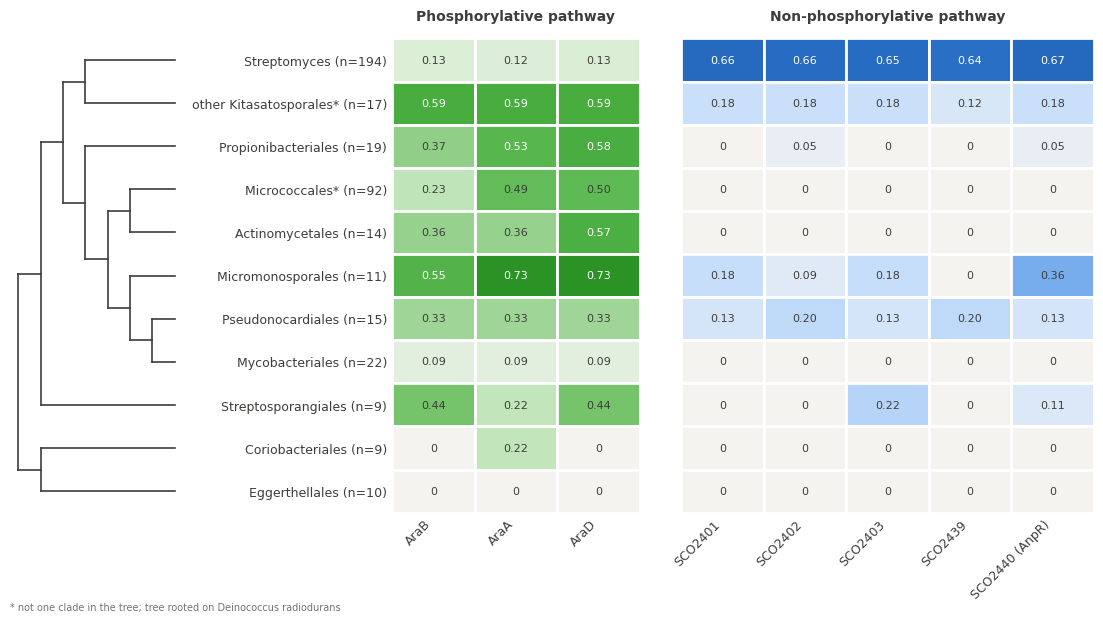

query_gene,AraB,AraA,AraD,SCO2401,SCO2402,SCO2403,SCO2439,SCO2440
Streptomyces,0.13,0.12,0.13,0.66,0.66,0.65,0.64,0.67
other Kitasatosporales,0.59,0.59,0.59,0.18,0.18,0.18,0.12,0.18
Propionibacteriales,0.37,0.53,0.58,0.00,0.05,0.00,0.00,0.05
Micrococcales,0.23,0.49,0.50,0.00,0.00,0.00,0.00,0.00
Actinomycetales,0.36,0.36,0.57,0.00,0.00,0.00,0.00,0.00
Micromonosporales,0.55,0.73,0.73,0.18,0.09,0.18,0.00,0.36
Pseudonocardiales,0.33,0.33,0.33,0.13,0.20,0.13,0.20,0.13
Mycobacteriales,0.09,0.09,0.09,0.00,0.00,0.00,0.00,0.00
Streptosporangiales,0.44,0.22,0.44,0.00,0.00,0.22,0.00,0.11
Coriobacteriales,0.00,0.22,0.00,0.00,0.00,0.00,0.00,0.00


In [15]:
# Step 11: Heatmap
# genes left out of the figure (still in the tables of steps 7 and 9)
HIDDEN_GENES = ["lacI-AraR", "SCO2407"]
# column labels in the figure (gene name if not listed)
GENE_LABELS = {"SCO2440": "SCO2440 (AnpR)"}
plot_pathways = {pathway: [gene for gene in genes if gene not in HIDDEN_GENES] for pathway, genes in PATHWAYS.items()}
plot_columns = [gene for genes in plot_pathways.values() for gene in genes]

fractions = contingency.loc[order_rows, plot_columns].div(contingency.loc[order_rows, "n_genomes"], axis=0)

# one hue per pathway, light -> dark: 0 sits close to the background, 1 is the darkest shade;
# vnz/Ara green and SCO blue, as in the iTOL datasets
CMAPS = {
    "vnz/Ara": LinearSegmentedColormap.from_list(
        "fraction_ara", ["#f4f3f0", "#d3ecce", "#9fd596", "#5fba55", "#33a02c", "#1f7a1a", "#135212"]
    ),
    "SCO": LinearSegmentedColormap.from_list(
        "fraction_sco", ["#f4f3f0", "#cde2fb", "#86b6ef", "#3987e5", "#256abf", "#104281", "#0d366b"]
    ),
}
INK = "#3d3d3a"       # text on light cells
INK_MUTED = "#73726c"
PATHWAY_GAP = 0.5     # blank space between the vnz/Ara and the SCO columns

# x position of each gene column, with the gap after the last vnz/Ara gene
n_ara = len(plot_pathways["vnz/Ara"])
x_pos = [i + (PATHWAY_GAP if i >= n_ara else 0) for i in range(len(plot_columns))]


def cladogram_coords(tree):
    """x = node depth (tips aligned on the right), y = row centre of each clade."""
    x, y = {}, {}

    def set_x(clade, depth):
        x[clade] = depth
        for child in clade.clades:
            set_x(child, depth + 1)

    set_x(tree.root, 0)
    max_depth = max(x.values())
    for row, tip in enumerate(tree.get_terminals()):
        x[tip] = max_depth
        y[tip] = row + 0.5

    def set_y(clade):
        if not clade.is_terminal():
            child_y = [set_y(child) for child in clade.clades]
            y[clade] = (min(child_y) + max(child_y)) / 2
        return y[clade]

    set_y(tree.root)
    return x, y


fig, (tree_ax, ax) = plt.subplots(
    1, 2, figsize=(0.7 * len(plot_columns) + 5.5, 0.42 * len(order_rows) + 1.6),
    gridspec_kw={"width_ratios": [1.3, 0.7 * len(plot_columns)]},
)

# order tree (topology only; branch lengths not drawn)
x, y = cladogram_coords(tree)
for clade in tree.find_clades(order="preorder"):
    if clade.is_terminal():
        continue
    child_y = [y[child] for child in clade.clades]
    tree_ax.plot([x[clade], x[clade]], [min(child_y), max(child_y)], color=INK, linewidth=1.2)
    for child in clade.clades:
        tree_ax.plot([x[clade], x[child]], [y[child], y[child]], color=INK, linewidth=1.2)
tree_ax.set_ylim(len(order_rows), 0)
tree_ax.set_xlim(-0.2, max(x.values()) + 0.1)
tree_ax.axis("off")

# heatmap
for row, order in enumerate(order_rows):
    for col, gene in enumerate(plot_columns):
        value = fractions.loc[order, gene]
        ax.add_patch(plt.Rectangle((x_pos[col], row), 1, 1, facecolor=CMAPS[GENE_TO_PATHWAY[gene]](value),
                                   edgecolor="white", linewidth=2))
        ax.text(x_pos[col] + 0.5, row + 0.5, f"{value:.2f}" if value else "0", ha="center", va="center",
                fontsize=8, color="white" if value > 0.5 else INK)

ax.set_xlim(0, x_pos[-1] + 1)
ax.set_ylim(len(order_rows), 0)
ax.set_xticks([x_ + 0.5 for x_ in x_pos], [GENE_LABELS.get(gene, gene) for gene in plot_columns], rotation=45, ha="right", fontsize=9, color=INK)
# * = the order is not one clade in the tree
ax.set_yticks([r + 0.5 for r in range(len(order_rows))],
              [f"{order}{'*' if order in not_monophyletic else ''} (n={contingency.loc[order, 'n_genomes']})"
               for order in order_rows], fontsize=9, color=INK)
ax.tick_params(length=0)
for side in ax.spines.values():
    side.set_visible(False)

# pathway names above their column blocks
for pathway, start, end in [("Phosphorylative pathway", 0, n_ara), ("Non-phosphorylative pathway", n_ara, len(plot_columns))]:
    middle = (x_pos[start] + x_pos[end - 1] + 1) / 2
    ax.text(middle, -0.35, pathway, ha="center", va="bottom", fontsize=10, color=INK, fontweight="bold")


if not_monophyletic:
    fig.text(0.01, 0.01, "* not one clade in the tree; tree rooted on Deinococcus radiodurans",
             fontsize=7, color=INK_MUTED)

fig.tight_layout()

FIGURE_FILE = PROJECT_DIR / "taxonomy_heatmap" / "results" / "order_heatmap.pdf"
fig.savefig(FIGURE_FILE, bbox_inches="tight")
print(f"Figure saved to {FIGURE_FILE}")
plt.show()

fractions.round(2)